<div align="center">
    <img src="../BGIT LOGO.png" width="400">
    <h1 style="font-size:20px;">
        This is a Linear Regression Problem. Therefore, the end goal is to identify potential biomarkers that influence Survival in Months in Secondary MIBC patients only. Use the steps below as a guide.
        - Soundarya Dhandapani
    </h1>
</div>



<h2 style="font-size:18px;">
    Install necessary libraries
</h2>

In [780]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso,Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error,r2_score


<h2 style="font-size:18px;">
    Read in necessary files for this assessment.
    
</h2>
<h2 style="font-size:18px;">
1.data_clinical_patient.txt
</h2>
<h2 style="font-size:18px;">
2.data_clinical_sample.txt
</h2>
<h2 style="font-size:18px;">
3.data_mrna_seq_v2_rsem
</h2>

In [781]:
#Reading files
rnaSeq = pd.read_csv("../data/data_mrna_seq_v2_rsem.txt", sep="\t") 
rnaSeq


,Hugo_Symbol,Entrez_Gene_Id,TCGA-2F-A9KP-01,TCGA-2F-A9KQ-01,TCGA-2F-A9KR-01,TCGA-2F-A9KT-01,TCGA-2F-A9KW-01,TCGA-4Z-AA7O-01,TCGA-4Z-AA7Q-01,TCGA-4Z-AA7S-01,...,TCGA-ZF-AA4X-01,TCGA-ZF-AA51-01,TCGA-ZF-AA52-01,TCGA-ZF-AA53-01,TCGA-ZF-AA54-01,TCGA-ZF-AA56-01,TCGA-ZF-AA58-01,TCGA-ZF-AA5H-01,TCGA-ZF-AA5N-01,TCGA-ZF-AA5P-01
0,NaN,100130426,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.4411,0.4216,0.0000,1.2270,0.0000
1,NaN,100133144,16.1382,13.3333,15.3523,14.0136,7.1159,16.6052,0.0000,23.2738,...,24.0360,0.0000,4.2992,0.0000,4.6306,5.8271,1.7032,3.3904,0.0000,7.0317
2,UBE2Q2P2,100134869,12.5759,10.7742,42.5810,17.6427,2.3091,8.6650,11.9205,13.7922,...,10.3812,5.2751,14.5465,6.8871,8.0213,7.8474,2.0911,1.1387,0.0000,4.0856
3,HMGB1P1,10357,137.8860,104.6780,146.4530,142.9620,176.8770,179.1990,96.9139,131.3010,...,58.4972,119.0880,91.4959,163.8500,83.2794,185.6730,210.1810,186.9380,155.3010,114.1130
4,NaN,10431,882.2310,954.1030,487.2100,954.7770,1586.0300,768.7450,662.2520,892.3300,...,841.2210,859.0810,753.8280,1646.6900,1702.4300,575.2100,1595.7000,1100.5700,1123.9300,778.2100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20526,ZYG11A,440590,17.0620,1.8544,1.8995,6.7835,51.3143,0.0000,15.2318,3.6608,...,23.6118,11.3037,1.7668,36.5014,94.1296,2.2056,143.3390,0.3235,15.9509,13.3407
20527,ZYG11B,79699,1526.4300,1571.1600,748.8600,878.4620,1493.8700,870.4900,615.8940,1285.4100,...,1311.4600,1003.7700,624.2640,431.1300,523.2790,697.8390,711.2140,671.9240,358.2820,887.7150
20528,ZYX,7791,3105.2900,3275.3800,4465.6200,3449.4100,2778.3000,4226.7700,5065.5600,3836.5600,...,2098.6500,2724.9400,6375.7400,11268.6000,7956.4800,5666.0800,9911.0500,9212.5000,6306.7500,14836.0000
20529,ZZEF1,23140,1467.7500,750.5800,910.7880,850.1980,2811.2900,712.8850,938.4110,842.4510,...,1735.2700,666.1640,724.3820,337.4660,1099.7000,752.9770,745.3630,911.3190,850.3070,1030.0200


In [782]:
#Reading files
sample = pd.read_csv("../data/data_clinical_sample.txt", sep="\t")

In [783]:
#Reading files
patient = pd.read_csv("../data/data_clinical_patient.txt", sep="\t")


<h2 style="font-size:18px;">
    Perform Data Cleaning, Data Wrangling and Merge datasets together when necessary and filter for patients with Secondary MIBC only. 
    
</h2>

In [784]:
# data cleaning of rna seq
rnaSeq = rnaSeq.dropna(subset=['Hugo_Symbol'])

rnaSeq = rnaSeq.drop_duplicates(subset=['Hugo_Symbol'])

rnaSeq = rnaSeq.set_index('Hugo_Symbol')

rnaSeq = rnaSeq.drop(columns=['Entrez_Gene_Id'])

rnaSeq = rnaSeq.T

rnaSeq.reset_index(inplace=True)

rnaSeq.rename(columns={'index': 'Sample ID'}, inplace=True)
rnaSeq

Hugo_Symbol,Sample ID,UBE2Q2P2,HMGB1P1,RNU12-2P,SSX9P,EZHIP,EFCAB8,SRP14P1,TRIM75P,SPATA31B1P,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,TCGA-2F-A9KP-01,12.5759,137.886,0.8323,0.0,0.0000,4.5776,2.0807,0.4161,0.0,...,718.119,969.621,37.0370,316.688,1420.720,17.0620,1526.430,3105.29,1467.750,860.591
1,TCGA-2F-A9KQ-01,10.7742,104.678,0.0000,0.0,0.0000,0.4636,2.3180,0.0000,0.0,...,532.536,795.086,60.2689,378.303,873.435,1.8544,1571.160,3275.38,750.580,621.233
2,TCGA-2F-A9KR-01,42.5810,146.453,2.3743,0.0,1.8995,1.4246,3.7989,0.0000,0.0,...,616.848,568.412,45.5869,470.115,1924.150,1.8995,748.860,4465.62,910.788,935.481
3,TCGA-2F-A9KT-01,17.6427,142.962,0.0000,0.0,5.0876,2.2612,6.2182,0.0000,0.0,...,726.625,1087.050,17.5240,281.515,938.383,6.7835,878.462,3449.41,850.198,630.865
4,TCGA-2F-A9KW-01,2.3091,176.877,0.0000,0.0,0.5236,1.5708,5.7598,0.0000,0.0,...,421.714,2055.190,25.6571,244.005,1160.330,51.3143,1493.870,2778.30,2811.290,746.151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,TCGA-ZF-AA56-01,7.8474,185.673,0.0000,0.0,0.0000,0.0000,3.0878,0.0000,0.0,...,551.566,1201.150,22.4967,220.997,745.038,2.2056,697.839,5666.08,752.977,619.321
292,TCGA-ZF-AA58-01,2.0911,210.181,0.0000,0.0,0.4216,1.2648,1.2648,0.0000,0.0,...,532.618,1059.440,37.5211,254.637,1037.100,143.3390,711.214,9911.05,745.363,548.904
293,TCGA-ZF-AA5H-01,1.1387,186.938,0.0000,0.0,0.6470,14.8813,2.9116,0.0000,0.0,...,520.105,1248.410,19.0869,186.663,498.200,0.3235,671.924,9212.50,911.319,1053.660
294,TCGA-ZF-AA5N-01,0.0000,155.301,1.2270,0.0,0.0000,2.4540,1.2270,0.0000,0.0,...,496.638,641.718,13.4969,121.472,534.969,15.9509,358.282,6306.75,850.307,380.368


In [785]:
# Data cleaning of sample file
sample = pd.read_csv("../data/data_clinical_sample.txt", sep="\t",skiprows=4)

#Filtering only sample id and type of MIBC column
sample = sample[['SAMPLE_ID','PATIENT_ID', 'PRIMARY_VS_SECONDARY']]


sample

,SAMPLE_ID,PATIENT_ID,PRIMARY_VS_SECONDARY
0,TCGA-2F-A9KP-01,TCGA-2F-A9KP,Primary MIBC
1,TCGA-2F-A9KQ-01,TCGA-2F-A9KQ,Primary MIBC
2,TCGA-2F-A9KR-01,TCGA-2F-A9KR,Primary MIBC
3,TCGA-2F-A9KT-01,TCGA-2F-A9KT,Primary MIBC
4,TCGA-2F-A9KW-01,TCGA-2F-A9KW,Primary MIBC
...,...,...,...
471,P-0009101-T01-IM5,P-0009101,Secondary MIBC
472,P-0009618-T01-IM5,P-0009618,Primary MIBC
473,P-0009743-T01-IM5,P-0009743,Secondary MIBC
474,P-0009846-T01-IM5,P-0009846,Primary MIBC


In [786]:
#PRIMARY_VS_SECONDARY count
sample['PRIMARY_VS_SECONDARY'].value_counts()


PRIMARY_VS_SECONDARY
Primary MIBC      398
Secondary MIBC     78
Name: count, dtype: int64

In [787]:
#Cleaning patient data
patient = pd.read_csv("../data/data_clinical_patient.txt", sep="\t",skiprows=4)

#Filtering only PATIENT_ID and OS Months
patient = patient[['PATIENT_ID', 'OS_MONTHS']]

patient

,PATIENT_ID,OS_MONTHS
0,TCGA-2F-A9KP,11.966992
1,TCGA-2F-A9KQ,94.881152
2,TCGA-2F-A9KR,104.645429
3,TCGA-2F-A9KT,108.952231
4,TCGA-2F-A9KW,8.350593
...,...,...
471,P-0009101,52.701000
472,P-0009618,44.088000
473,P-0009743,3.978000
474,P-0009846,9.534000


In [788]:
#Merging of RNAseq and sample data
merged = pd.merge(rnaSeq,sample,left_on='Sample ID',right_on='SAMPLE_ID')
merged

,Sample ID,UBE2Q2P2,HMGB1P1,RNU12-2P,SSX9P,EZHIP,EFCAB8,SRP14P1,TRIM75P,SPATA31B1P,...,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,SAMPLE_ID,PATIENT_ID,PRIMARY_VS_SECONDARY
0,TCGA-2F-A9KP-01,12.5759,137.886,0.8323,0.0,0.0000,4.5776,2.0807,0.4161,0.0,...,316.688,1420.720,17.0620,1526.430,3105.29,1467.750,860.591,TCGA-2F-A9KP-01,TCGA-2F-A9KP,Primary MIBC
1,TCGA-2F-A9KQ-01,10.7742,104.678,0.0000,0.0,0.0000,0.4636,2.3180,0.0000,0.0,...,378.303,873.435,1.8544,1571.160,3275.38,750.580,621.233,TCGA-2F-A9KQ-01,TCGA-2F-A9KQ,Primary MIBC
2,TCGA-2F-A9KR-01,42.5810,146.453,2.3743,0.0,1.8995,1.4246,3.7989,0.0000,0.0,...,470.115,1924.150,1.8995,748.860,4465.62,910.788,935.481,TCGA-2F-A9KR-01,TCGA-2F-A9KR,Primary MIBC
3,TCGA-2F-A9KT-01,17.6427,142.962,0.0000,0.0,5.0876,2.2612,6.2182,0.0000,0.0,...,281.515,938.383,6.7835,878.462,3449.41,850.198,630.865,TCGA-2F-A9KT-01,TCGA-2F-A9KT,Primary MIBC
4,TCGA-2F-A9KW-01,2.3091,176.877,0.0000,0.0,0.5236,1.5708,5.7598,0.0000,0.0,...,244.005,1160.330,51.3143,1493.870,2778.30,2811.290,746.151,TCGA-2F-A9KW-01,TCGA-2F-A9KW,Primary MIBC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,TCGA-ZF-AA56-01,7.8474,185.673,0.0000,0.0,0.0000,0.0000,3.0878,0.0000,0.0,...,220.997,745.038,2.2056,697.839,5666.08,752.977,619.321,TCGA-ZF-AA56-01,TCGA-ZF-AA56,Primary MIBC
292,TCGA-ZF-AA58-01,2.0911,210.181,0.0000,0.0,0.4216,1.2648,1.2648,0.0000,0.0,...,254.637,1037.100,143.3390,711.214,9911.05,745.363,548.904,TCGA-ZF-AA58-01,TCGA-ZF-AA58,Primary MIBC
293,TCGA-ZF-AA5H-01,1.1387,186.938,0.0000,0.0,0.6470,14.8813,2.9116,0.0000,0.0,...,186.663,498.200,0.3235,671.924,9212.50,911.319,1053.660,TCGA-ZF-AA5H-01,TCGA-ZF-AA5H,Primary MIBC
294,TCGA-ZF-AA5N-01,0.0000,155.301,1.2270,0.0,0.0000,2.4540,1.2270,0.0000,0.0,...,121.472,534.969,15.9509,358.282,6306.75,850.307,380.368,TCGA-ZF-AA5N-01,TCGA-ZF-AA5N,Primary MIBC


In [789]:
#Removed missing values
merged = merged.dropna(subset=['PRIMARY_VS_SECONDARY'])
merged

,Sample ID,UBE2Q2P2,HMGB1P1,RNU12-2P,SSX9P,EZHIP,EFCAB8,SRP14P1,TRIM75P,SPATA31B1P,...,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,SAMPLE_ID,PATIENT_ID,PRIMARY_VS_SECONDARY
0,TCGA-2F-A9KP-01,12.5759,137.886,0.8323,0.0,0.0000,4.5776,2.0807,0.4161,0.0,...,316.688,1420.720,17.0620,1526.430,3105.29,1467.750,860.591,TCGA-2F-A9KP-01,TCGA-2F-A9KP,Primary MIBC
1,TCGA-2F-A9KQ-01,10.7742,104.678,0.0000,0.0,0.0000,0.4636,2.3180,0.0000,0.0,...,378.303,873.435,1.8544,1571.160,3275.38,750.580,621.233,TCGA-2F-A9KQ-01,TCGA-2F-A9KQ,Primary MIBC
2,TCGA-2F-A9KR-01,42.5810,146.453,2.3743,0.0,1.8995,1.4246,3.7989,0.0000,0.0,...,470.115,1924.150,1.8995,748.860,4465.62,910.788,935.481,TCGA-2F-A9KR-01,TCGA-2F-A9KR,Primary MIBC
3,TCGA-2F-A9KT-01,17.6427,142.962,0.0000,0.0,5.0876,2.2612,6.2182,0.0000,0.0,...,281.515,938.383,6.7835,878.462,3449.41,850.198,630.865,TCGA-2F-A9KT-01,TCGA-2F-A9KT,Primary MIBC
4,TCGA-2F-A9KW-01,2.3091,176.877,0.0000,0.0,0.5236,1.5708,5.7598,0.0000,0.0,...,244.005,1160.330,51.3143,1493.870,2778.30,2811.290,746.151,TCGA-2F-A9KW-01,TCGA-2F-A9KW,Primary MIBC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,TCGA-ZF-AA56-01,7.8474,185.673,0.0000,0.0,0.0000,0.0000,3.0878,0.0000,0.0,...,220.997,745.038,2.2056,697.839,5666.08,752.977,619.321,TCGA-ZF-AA56-01,TCGA-ZF-AA56,Primary MIBC
292,TCGA-ZF-AA58-01,2.0911,210.181,0.0000,0.0,0.4216,1.2648,1.2648,0.0000,0.0,...,254.637,1037.100,143.3390,711.214,9911.05,745.363,548.904,TCGA-ZF-AA58-01,TCGA-ZF-AA58,Primary MIBC
293,TCGA-ZF-AA5H-01,1.1387,186.938,0.0000,0.0,0.6470,14.8813,2.9116,0.0000,0.0,...,186.663,498.200,0.3235,671.924,9212.50,911.319,1053.660,TCGA-ZF-AA5H-01,TCGA-ZF-AA5H,Primary MIBC
294,TCGA-ZF-AA5N-01,0.0000,155.301,1.2270,0.0,0.0000,2.4540,1.2270,0.0000,0.0,...,121.472,534.969,15.9509,358.282,6306.75,850.307,380.368,TCGA-ZF-AA5N-01,TCGA-ZF-AA5N,Primary MIBC


In [790]:
#PRIMARY_VS_SECONDARY count
merged['PRIMARY_VS_SECONDARY'].value_counts()


PRIMARY_VS_SECONDARY
Primary MIBC      258
Secondary MIBC     38
Name: count, dtype: int64

In [791]:
merged = merged.drop('SAMPLE_ID', axis=1)
merged

,Sample ID,UBE2Q2P2,HMGB1P1,RNU12-2P,SSX9P,EZHIP,EFCAB8,SRP14P1,TRIM75P,SPATA31B1P,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,PATIENT_ID,PRIMARY_VS_SECONDARY
0,TCGA-2F-A9KP-01,12.5759,137.886,0.8323,0.0,0.0000,4.5776,2.0807,0.4161,0.0,...,37.0370,316.688,1420.720,17.0620,1526.430,3105.29,1467.750,860.591,TCGA-2F-A9KP,Primary MIBC
1,TCGA-2F-A9KQ-01,10.7742,104.678,0.0000,0.0,0.0000,0.4636,2.3180,0.0000,0.0,...,60.2689,378.303,873.435,1.8544,1571.160,3275.38,750.580,621.233,TCGA-2F-A9KQ,Primary MIBC
2,TCGA-2F-A9KR-01,42.5810,146.453,2.3743,0.0,1.8995,1.4246,3.7989,0.0000,0.0,...,45.5869,470.115,1924.150,1.8995,748.860,4465.62,910.788,935.481,TCGA-2F-A9KR,Primary MIBC
3,TCGA-2F-A9KT-01,17.6427,142.962,0.0000,0.0,5.0876,2.2612,6.2182,0.0000,0.0,...,17.5240,281.515,938.383,6.7835,878.462,3449.41,850.198,630.865,TCGA-2F-A9KT,Primary MIBC
4,TCGA-2F-A9KW-01,2.3091,176.877,0.0000,0.0,0.5236,1.5708,5.7598,0.0000,0.0,...,25.6571,244.005,1160.330,51.3143,1493.870,2778.30,2811.290,746.151,TCGA-2F-A9KW,Primary MIBC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,TCGA-ZF-AA56-01,7.8474,185.673,0.0000,0.0,0.0000,0.0000,3.0878,0.0000,0.0,...,22.4967,220.997,745.038,2.2056,697.839,5666.08,752.977,619.321,TCGA-ZF-AA56,Primary MIBC
292,TCGA-ZF-AA58-01,2.0911,210.181,0.0000,0.0,0.4216,1.2648,1.2648,0.0000,0.0,...,37.5211,254.637,1037.100,143.3390,711.214,9911.05,745.363,548.904,TCGA-ZF-AA58,Primary MIBC
293,TCGA-ZF-AA5H-01,1.1387,186.938,0.0000,0.0,0.6470,14.8813,2.9116,0.0000,0.0,...,19.0869,186.663,498.200,0.3235,671.924,9212.50,911.319,1053.660,TCGA-ZF-AA5H,Primary MIBC
294,TCGA-ZF-AA5N-01,0.0000,155.301,1.2270,0.0,0.0000,2.4540,1.2270,0.0000,0.0,...,13.4969,121.472,534.969,15.9509,358.282,6306.75,850.307,380.368,TCGA-ZF-AA5N,Primary MIBC


In [792]:
#Removed missing values
merged = merged.dropna(subset=['PRIMARY_VS_SECONDARY'])
merged

,Sample ID,UBE2Q2P2,HMGB1P1,RNU12-2P,SSX9P,EZHIP,EFCAB8,SRP14P1,TRIM75P,SPATA31B1P,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,PATIENT_ID,PRIMARY_VS_SECONDARY
0,TCGA-2F-A9KP-01,12.5759,137.886,0.8323,0.0,0.0000,4.5776,2.0807,0.4161,0.0,...,37.0370,316.688,1420.720,17.0620,1526.430,3105.29,1467.750,860.591,TCGA-2F-A9KP,Primary MIBC
1,TCGA-2F-A9KQ-01,10.7742,104.678,0.0000,0.0,0.0000,0.4636,2.3180,0.0000,0.0,...,60.2689,378.303,873.435,1.8544,1571.160,3275.38,750.580,621.233,TCGA-2F-A9KQ,Primary MIBC
2,TCGA-2F-A9KR-01,42.5810,146.453,2.3743,0.0,1.8995,1.4246,3.7989,0.0000,0.0,...,45.5869,470.115,1924.150,1.8995,748.860,4465.62,910.788,935.481,TCGA-2F-A9KR,Primary MIBC
3,TCGA-2F-A9KT-01,17.6427,142.962,0.0000,0.0,5.0876,2.2612,6.2182,0.0000,0.0,...,17.5240,281.515,938.383,6.7835,878.462,3449.41,850.198,630.865,TCGA-2F-A9KT,Primary MIBC
4,TCGA-2F-A9KW-01,2.3091,176.877,0.0000,0.0,0.5236,1.5708,5.7598,0.0000,0.0,...,25.6571,244.005,1160.330,51.3143,1493.870,2778.30,2811.290,746.151,TCGA-2F-A9KW,Primary MIBC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,TCGA-ZF-AA56-01,7.8474,185.673,0.0000,0.0,0.0000,0.0000,3.0878,0.0000,0.0,...,22.4967,220.997,745.038,2.2056,697.839,5666.08,752.977,619.321,TCGA-ZF-AA56,Primary MIBC
292,TCGA-ZF-AA58-01,2.0911,210.181,0.0000,0.0,0.4216,1.2648,1.2648,0.0000,0.0,...,37.5211,254.637,1037.100,143.3390,711.214,9911.05,745.363,548.904,TCGA-ZF-AA58,Primary MIBC
293,TCGA-ZF-AA5H-01,1.1387,186.938,0.0000,0.0,0.6470,14.8813,2.9116,0.0000,0.0,...,19.0869,186.663,498.200,0.3235,671.924,9212.50,911.319,1053.660,TCGA-ZF-AA5H,Primary MIBC
294,TCGA-ZF-AA5N-01,0.0000,155.301,1.2270,0.0,0.0000,2.4540,1.2270,0.0000,0.0,...,13.4969,121.472,534.969,15.9509,358.282,6306.75,850.307,380.368,TCGA-ZF-AA5N,Primary MIBC


<h2 style="font-size:18px;">
    Make sure that you have a matrix/dataframe where columns are gene names and rows are patient samples. Bonus points if PCA plot is attempted.
    
</h2>

In [ ]:
#PCA plot has been performed for the scaled train data below.

<h2 style="font-size:18px;">
    Make sure that you also have a column for Overall Survival (Months) as you prepare the dataset for Machine Learning. Drop extra columns or duplicated columns if necessary. Show that the gene names in the columns are unique.
    
</h2>

In [793]:
#Merging overall survival months to the table
merged = pd.merge(merged, patient,left_on='PATIENT_ID',right_on='PATIENT_ID')
merged = merged.drop('PATIENT_ID',axis=1)

#Dropped duplicate gene names
merged.columns.drop_duplicates(keep='first')

#Removing Primary MIBC data 
merged = merged[~merged["PRIMARY_VS_SECONDARY"].str.contains("Primary MIBC", na=False)]

#Removing Primary vs Secondary MIBC column
merged = merged.drop('PRIMARY_VS_SECONDARY',axis=1)
merged





,Sample ID,UBE2Q2P2,HMGB1P1,RNU12-2P,SSX9P,EZHIP,EFCAB8,SRP14P1,TRIM75P,SPATA31B1P,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,OS_MONTHS
13,TCGA-4Z-AA84-01,4.2453,129.9650,0.0000,0.0000,1.5627,13.5434,1.0418,0.0000,0.0000,...,892.3040,32.8168,262.0130,1024.610,153.6660,682.380,9900.77,827.191,620.393,15.123122
21,TCGA-BT-A42C-01,5.8262,249.3560,0.3239,0.0000,11.6590,0.3239,11.9828,0.0000,0.0000,...,1539.9600,33.6815,251.9630,1471.300,94.2434,783.742,2467.49,1139.020,554.125,28.701055
40,TCGA-CU-A72E-01,9.7411,150.1680,0.8220,0.0000,11.0974,2.0551,5.7542,0.0000,0.0000,...,849.5680,25.0719,199.3420,1048.910,10.2754,594.328,8103.16,1016.850,739.827,13.577933
69,TCGA-DK-A3X1-01,6.9033,273.8880,0.0000,0.0000,1.6837,0.0000,8.4187,0.0000,0.5612,...,800.8980,20.2049,228.4270,784.061,8.4187,805.388,2591.27,361.442,597.727,66.048591
70,TCGA-DK-A3X2-01,13.9497,195.7440,0.3743,0.0000,14.2229,1.4971,1.1229,0.7486,0.0000,...,2754.3700,35.1829,221.9520,1436.890,8.6086,1083.560,2147.28,1318.610,1531.210,17.983365
72,TCGA-DK-A6AW-01,4.5764,229.3440,0.0000,0.0000,0.0000,9.5465,5.3699,0.0000,0.0000,...,599.0450,16.7064,341.2890,1194.510,2.3866,499.403,6181.38,1052.510,498.210,53.292567
74,TCGA-DK-A6B2-01,3.4506,143.6640,0.0000,0.0000,0.0000,3.7688,2.0938,0.0000,0.0000,...,1398.6600,41.0385,298.1580,1617.670,50.2513,907.454,3783.50,1149.500,718.593,15.682020
75,TCGA-DK-A6B5-01,4.3817,229.0250,0.3381,0.0000,7.7762,9.1286,2.0286,0.0000,0.0000,...,949.0320,15.2143,227.8760,1269.880,50.3761,1201.930,3504.69,531.485,650.156,50.695335
77,TCGA-DK-AA6M-01,0.0000,162.6290,0.6745,0.0000,0.0000,2.0234,2.6979,0.0000,0.0000,...,538.2290,10.7916,130.1730,786.435,0.0000,448.524,8517.24,818.135,496.412,52.010389
80,TCGA-DK-AA6R-01,7.5259,202.4130,0.0000,0.0000,0.0000,1.4308,1.4308,0.0000,0.0000,...,1133.6600,42.4466,320.4960,908.549,69.6316,745.916,5614.88,656.731,491.713,165.729691


<h2 style="font-size:18px;">
    Prepare data for Machine Learning by creating your y and X matrices. Check for missing values (missing values can be replaced with 0 or filter out NA according to your logic). Use pandas and ensure numbers are numeric.
    
</h2>

In [794]:
#Preparing X axis
X = merged.drop(columns=['Sample ID', 'OS_MONTHS'])

top_genes = X.var().sort_values(
    ascending=False
).head(2000).index

X = X[top_genes]
X

,ADAM6,COL1A1,H19,COL3A1,BMS1P20,COL1A2,IGF2,PABPC1,KRT13,KRT17,...,SPATS2L,MTSS1,ZMPSTE24,GDE1,RAI14,SCARA3,ARL8B,ATP5D,NGFRAP1,RAD23A
13,1.390900e+04,32000.00,919.911,17872.600,8035.180,18942.000,2686.3500,149029.0,338.5860,862.0910,...,3833.31,53.1319,1055.870,8495.900,756.348,23.9615,3652.04,4499.540,449.538,7728.09
21,5.583250e+03,7345.80,1368.960,4821.960,3250.180,4575.820,317.1860,31276.2,1333.3300,21108.3000,...,3139.50,554.7730,2120.640,3342.560,2074.330,199.8220,5415.27,1352.440,2149.790,3126.22
40,1.550940e+03,95478.80,39485.000,58199.300,764.164,58534.700,2027.5400,61861.1,445402.0000,45719.7000,...,2601.73,4939.1700,1344.430,2236.740,2387.180,863.1320,3181.67,2591.040,2401.970,4691.33
69,2.150410e+03,65597.30,596940.000,27420.200,2043.730,31240.100,1279.0800,320726.0,3555.4900,24258.2000,...,1954.26,1533.3200,2059.770,4250.320,3767.640,1889.1500,1997.47,2083.340,3323.140,7080.12
70,7.565420e+02,11200.50,2546.270,6322.820,1471.540,6256.570,227.5660,68656.1,293244.0000,28986.2000,...,1112.01,808.4590,2314.590,973.145,530.364,315.8980,3000.66,1393.470,2756.990,4411.72
72,3.789320e+02,7059.07,2143.790,3170.640,392.942,3640.810,14470.5000,43874.7,28748.2000,4313.2500,...,1045.94,116.9450,711.217,1473.750,225.537,332.3390,1978.52,6087.710,1180.790,5121.12
74,9.336690e+04,116719.00,251833.000,88337.500,35841.800,76149.900,33642.9000,89579.6,31339.2000,20679.2000,...,5391.54,4474.8700,1448.490,2869.770,2388.190,2308.6300,1789.36,956.449,4435.090,2777.64
75,3.761680e+03,28333.70,3417.800,13109.600,2604.650,18007.300,463.2370,12152.1,24189.7000,40889.2000,...,1935.59,2154.0000,2453.550,1968.390,3774.150,3230.1600,1721.24,742.118,2115.120,1803.06
77,2.081740e+04,66501.60,58802.500,24570.400,8096.630,29840.700,1087.9200,38612.2,1200.5600,347768.0000,...,4116.98,1127.0300,1451.460,1347.600,3536.930,71.4941,2316.81,2484.760,1982.950,4801.57
80,2.899440e+03,45798.50,119948.000,28373.000,3205.250,26965.100,193.1560,33267.2,97404.6000,184231.0000,...,2549.18,3107.6700,2107.070,838.917,1261.950,804.5780,3491.12,1735.540,3369.980,4445.45


In [795]:
#Creating Y axis
Y = merged['OS_MONTHS']

<h2 style="font-size:18px;">
    * Hint * - Use sklearn.linear_model and import Ridge and Ridge as this is a Linear Regression Problem. 
</h2>

<h2 style="font-size:18px;">
    Choose two machine learning models and identify top genes that can be potential biomarkers
    
</h2>

In [796]:
#Creating train and test data frame

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=24
)

In [797]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


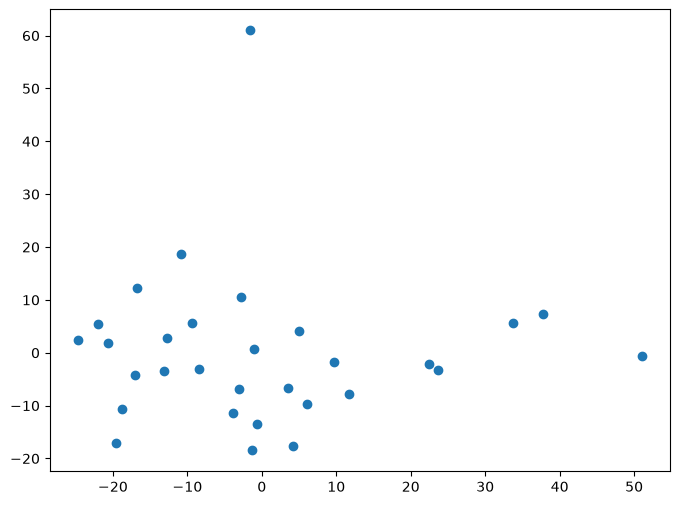

In [798]:

#Creating PCA plots
pca = PCA(n_components=30)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1]
)


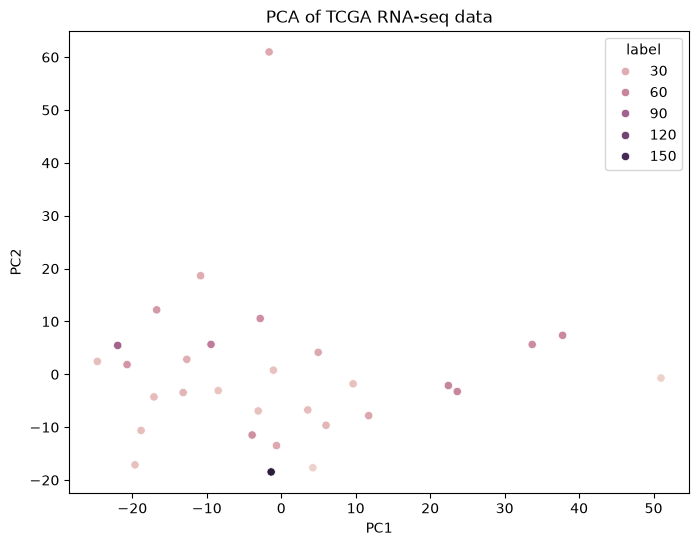

In [799]:
#PCA plot with labels
pca_df = pd.DataFrame(
    X_train_pca,
    columns=[f"PC{i+1}" for i in range(30)]
)
pca_df["label"] = y_train.values

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='label'
)

plt.title("PCA of TCGA RNA-seq data")
plt.show()

In [800]:
#Running Lasso model
modelLasso = Lasso(
    max_iter=1000, random_state=24
)

modelLasso.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",24
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [801]:
#Running Ridge model
modelRidge = Ridge(
    max_iter=1000, random_state=24
)

modelRidge.fit(X_train_scaled, y_train)


,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",1000
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",24
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"pos

<h2 style="font-size:18px;">
  * Hint * - For Feature Selection / Potential Biomarkers Identification process, use model.coef_ function. 
</h2>

In [802]:
#Getting lasso Co-efficients
lassoCoeff = modelLasso.coef_

#Creating table
lassoCoeffTable = pd.DataFrame({"Gene": X_train.columns, "Coeff": lassoCoeff})
lassoCoeffTable





,Gene,Coeff
0,ADAM6,0.0
1,COL1A1,-0.0
2,H19,0.0
3,COL3A1,-0.0
4,BMS1P20,0.0
...,...,...
1995,SCARA3,-0.0
1996,ARL8B,-0.0
1997,ATP5D,0.0
1998,NGFRAP1,0.0


In [803]:
#Getting ridge Co-efficients
ridgeCoeff = modelRidge.coef_

#Creating table
ridgeCoeffTable = pd.DataFrame({"Gene": X_train.columns, "Coeff": ridgeCoeff})

ridgeCoeffTable



,Gene,Coeff
0,ADAM6,0.130095
1,COL1A1,-0.055107
2,H19,-0.031115
3,COL3A1,-0.057368
4,BMS1P20,0.133130
...,...,...
1995,SCARA3,-0.084737
1996,ARL8B,-0.029168
1997,ATP5D,0.058737
1998,NGFRAP1,0.119398


<h2 style="font-size:18px;">
  1.For Lasso Regression, identify genes whose coefficients are not 0. For Ridge Regression, rank the genes in order of importance, with most important on top. 
</h2>

In [804]:
#Removing Zeros lasso model
lassoSelected = lassoCoeffTable[lassoCoeffTable["Coeff"] != 0]

#Converting to absolute value
lassoSelected["absCoeff"] = lassoSelected["Coeff"].abs()

#Sorting in Descending order
lassoSelected = lassoSelected.sort_values("absCoeff", ascending=False)

#Selecting top genes
lassoSelected = lassoSelected.head(20)

lassoSelected 



,Gene,Coeff,absCoeff
943,SERPINB1,11.323214,11.323214
1930,WIF1,5.958407,5.958407
659,FGFBP1,4.679150,4.679150
631,GDI2,4.426532,4.426532
493,SH3BGRL3,4.227821,4.227821
1118,HES1,4.023478,4.023478
765,CA12,3.801934,3.801934
1051,MAT2A,-2.555540,2.555540
429,MSN,2.280712,2.280712
1535,LTBP3,-2.066538,2.066538


In [805]:

#Removing Zeros ridge model
ridgeSelected = ridgeCoeffTable[ridgeCoeffTable["Coeff"] != 0]

#Converting to absolute value
ridgeSelected["absCoeff"] =ridgeSelected["Coeff"].abs()

#Sorting in Descending order
ridgeSelected =ridgeSelected.sort_values("absCoeff", ascending=False)

#Selecting top genes
ridgeSelected = ridgeSelected.head(20)

ridgeSelected 

,Gene,Coeff,absCoeff
516,SPRR1A,0.462062,0.462062
1081,SPRR2A,0.461805,0.461805
659,FGFBP1,0.448012,0.448012
973,TGM1,0.443771,0.443771
943,SERPINB1,0.442772,0.442772
1493,UBA6,0.437375,0.437375
992,CKB,0.433057,0.433057
24,KRT14,0.416545,0.416545
113,CD59,0.398838,0.398838
870,SERPINB2,0.396561,0.396561


<h2 style="font-size:18px;">
2. Explain your results. Explain any genes which appear as potential biomarkers in both models. Do research online and explain why some genes could be biologically relevant and used as a target for further research?
</h2>

In [806]:
#Finding common genes from both the models

lassoTop = set(lassoSelected.head(20)["Gene"])
ridgeTop = set(ridgeSelected.head(20)["Gene"])

commonGenes = lassoTop.intersection(ridgeTop)
commonGenes               

{'FGFBP1', 'GDI2', 'KRT14', 'SERPINB1', 'WIF1'}

In [807]:
finalBiomarkerTable = pd.merge(lassoSelected[["Gene","Coeff"]],ridgeSelected[["Gene","Coeff"]],on="Gene", suffixes=("_lasso","_ridge"))
finalBiomarkerTable


,Gene,Coeff_lasso,Coeff_ridge
0,SERPINB1,11.323214,0.442772
1,WIF1,5.958407,0.353459
2,FGFBP1,4.679150,0.448012
3,GDI2,4.426532,0.320899
4,KRT14,1.075078,0.416545


hjhh

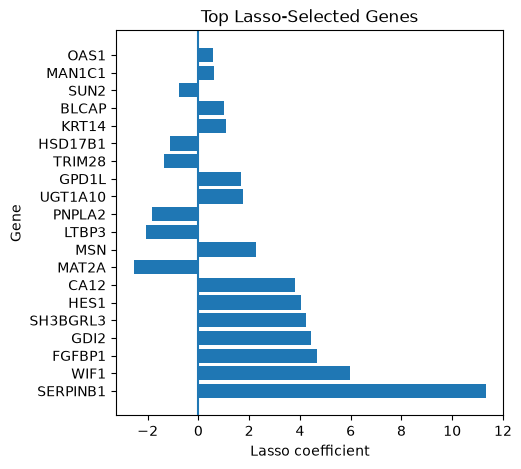

In [808]:
#Visualization of top biomarker genes-lasso plot
plt.figure(figsize=(5,5))
plt.barh(lassoSelected.head(20)["Gene"],lassoSelected.head(20)["Coeff"])

plt.xlabel("Lasso coefficient")
plt.ylabel("Gene")
plt.title("Top Lasso-Selected Genes")

plt.axvline(0)
plt.show()

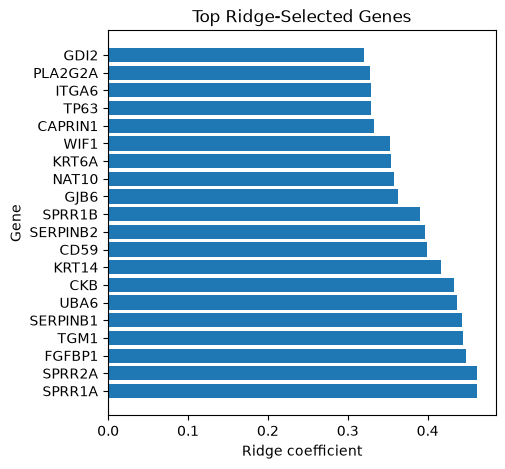

In [809]:
#Visualization of top biomarker genes-ridge plot
plt.figure(figsize=(5,5))
plt.barh(ridgeSelected.head(20)["Gene"],ridgeSelected.head(20)["Coeff"])

plt.xlabel("Ridge coefficient")
plt.ylabel("Gene")
plt.title("Top Ridge-Selected Genes")

plt.axvline(0)
plt.show()

<h2 style="font-size:18px;">
3. Why is one method better than the other?
</h2>

<h2 style="font-size:18px;">
4. What steps can you carry out to determine if one method performed better than the other?
</h2>

In [810]:

#Predicting
lassoPrediction = modelLasso.predict(X_test_scaled)
ridgePrediction = modelRidge.predict(X_test_scaled)


In [812]:
#Cross Evaluating the models
lassoR2score = r2_score(y_test,lassoPrediction)

ridgeR2score = r2_score(y_test, ridgePrediction)

print(f"LassoR2score: ", lassoR2score, "RidgeR2score: ",ridgeR2score)

#evaluating mean ERROR
lassoMeanError = mean_absolute_error(y_test,lassoPrediction)
ridgeMeanError = mean_absolute_error(y_test,ridgePrediction)
print(f"LassoAbsoluteMeanError: ", lassoMeanError, "RidgeAbsoluteMeanError:",ridgeMeanError)


LassoR2score:  -70229.792236205 RidgeR2score:  -518.0101704851373
LassoAbsoluteMeanError:  1738.9454736048529 RidgeAbsoluteMeanError: 172.3944075725051
